# Narrowband linear spherical harmonic
- basic notebook that samples IPTA MDC1 in linspharm basis using discovery -- new specspat formalism

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

In [5]:
isoc1ms = np.array([np.sqrt(4*np.pi), 1, 0, 0])
notjaxalm = dac.notjax_clm2alm(isoc1ms)

AttributeError: module 'discovery.anis_coefficients' has no attribute 'notjax_clm2alm'

In [6]:
import jax_healpy as jhp
alms = dac.clm2alm(isoc1ms)
print(np.allclose(alms, notjaxalm))
hp.mollview(hp.alm2map(alms, nside=16))

NameError: name 'notjaxalm' is not defined

In [44]:
dac.hp_Alm_getsize(lmax=1)

3

In [ ]:
alms

(3,)

In [55]:
jhp.alm2map(alms, lmax=1, nside=1, healpy_ordering=True)

Array([0.74248387+0.j, 0.74248387+0.j, 1.25751613+0.j, 1.25751613+0.j,
       1.        +0.j, 0.51139749+0.j, 1.        +0.j, 1.48860251+0.j,
       0.74248387+0.j, 0.74248387+0.j, 1.25751613+0.j, 1.25751613+0.j],      dtype=complex128)

## model set up

In [7]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 2 # freq components
lmx = 2
nsi=1
nclms = (lmx+1)**2-1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})


psrpos = np.array([p.pos for p in psrs])

lsphorfs = []
nclms = []
for c in range(comps):
    linsph = dac.get_linspharm_orf(psrpos, lmax=lmx)
    pjitlsph = functools.partial(linsph, c00=np.sqrt(4*np.pi))
    lsphorfs.append(pjitlsph)
    nclms.append((lmx+1)**2-1)


glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.freespectrum],
                                    [lsphorfs],
                                    components=comps, T=T, name='gw', nbasis=[nclms])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
    for c in range(comps):
        paramdict[f'gw_clm_f{c}({nclms[c]})'] = params[aniparamct:aniparamct+nclms[c]]
        aniparamct += nclms[c]

    paramdict[f'gw_log10_rho({comps})'] = params[-comps:]
    return m_mdc.logL(paramdict)


    

In [8]:
numberofclms = sum(nclms)
tstpars = jnp.zeros(numberofclms + comps)
tstpars = tstpars.at[-comps:].set(np.ones(comps)*-6.0)
# tstpars = tstpars.at[-2].set(-7)
# tstpars = tstpars.at[-1].set(-6)

constrn_like(tstpars)

Array(40822.20776774, dtype=float64)

In [60]:
nparams = np.sum(nclms) + comps

In [61]:
tstpars={}
c1m1 = -1

tstpars['gw_clm_f0(8)'] = np.zeros(nclms[0])
tstpars['gw_clm_f0(8)'][0] = c1m1
tstpars['gw_clm_f1(8)'] = np.zeros(nclms[1])
tstpars['gw_log10_rho(2)'] = np.ones(comps)*-6.0

pararr = np.zeros(nparams)
pararr[0] = c1m1
pararr[-2:] = np.ones(comps)*-6.0
constrn_like(pararr)

Array(40811.185684, dtype=float64)

In [149]:
fidmat = m_mdc.globalgp.Phi_inv(tstpars)[0]
phimat = m_mdc.globalgp.Phi.getN(tstpars)

In [150]:
manualinv = np.linalg.inv(phimat)

In [151]:
maneival, maneivec = np.linalg.eigh(manualinv)

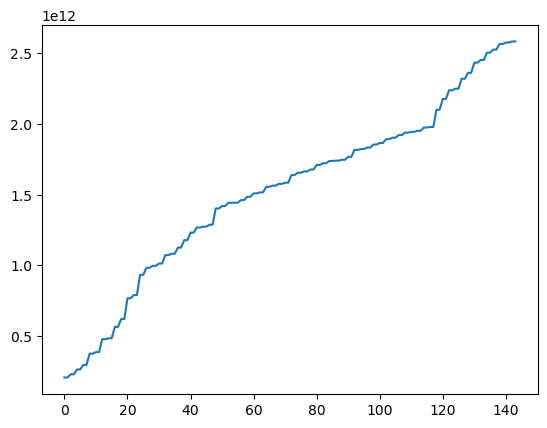

In [152]:
plt.plot(maneival)

In [162]:
# super simple cond num sweeps

clmsweep = np.linspace(-5, 5, 100)
condnums = np.zeros((numberofclms, len(clmsweep)))

for j in range(numberofclms):
    for i in range(len(clmsweep)):
        tstpars={}
        tstpars['gw_clm_f0(8)'] = np.zeros(nclms[0])
        tstpars['gw_clm_f1(8)'] = np.zeros(nclms[1])
        if j < nclms[0]:
            tstpars['gw_clm_f0(8)'][j] = clmsweep[i]
        else:
            tstpars['gw_clm_f1(8)'][j-nclms[0]] = clmsweep[i]
        tstpars['gw_log10_rho(2)'] = np.ones(comps)*-6.0
        fidmat = m_mdc.globalgp.Phi_inv(tstpars)[0]
        condnums[j, i] = np.linalg.cond(fidmat)


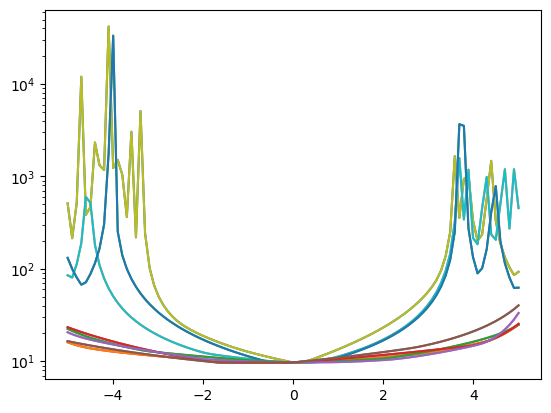

In [163]:
for j in range(numberofclms):
    plt.plot(clmsweep, condnums[j, :])
plt.yscale('log')

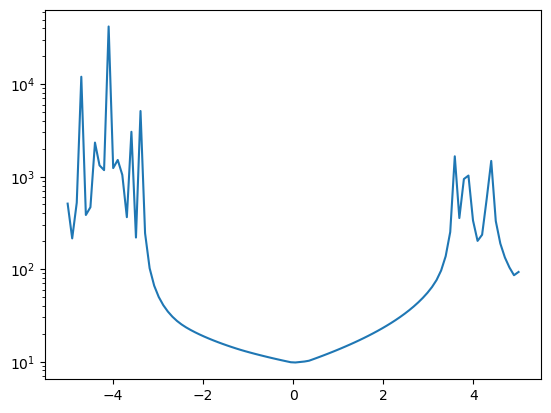

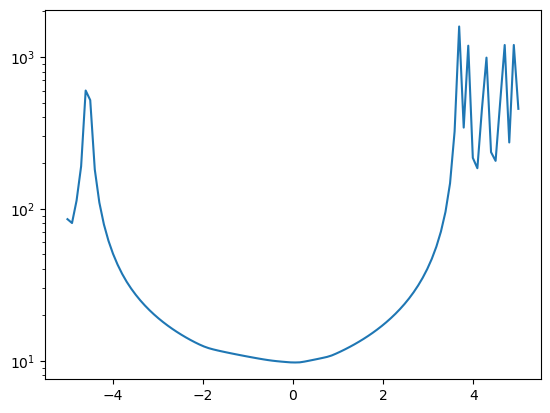

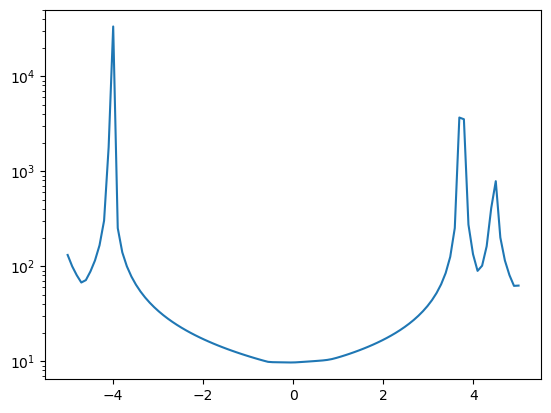

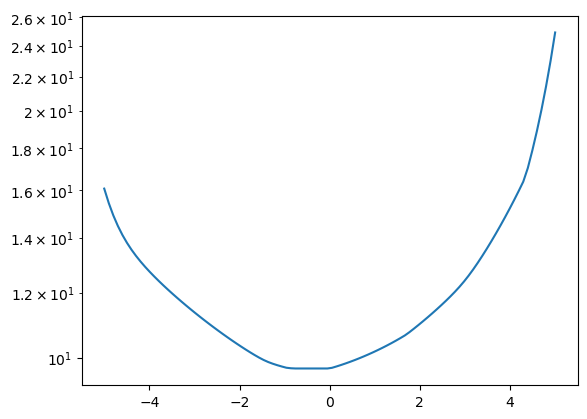

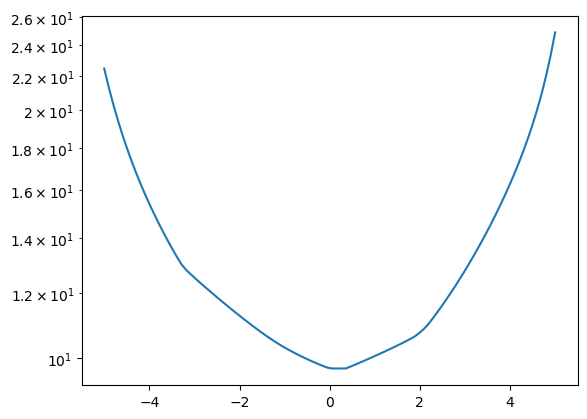

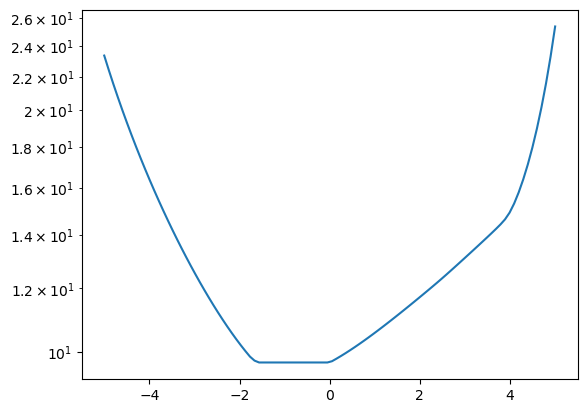

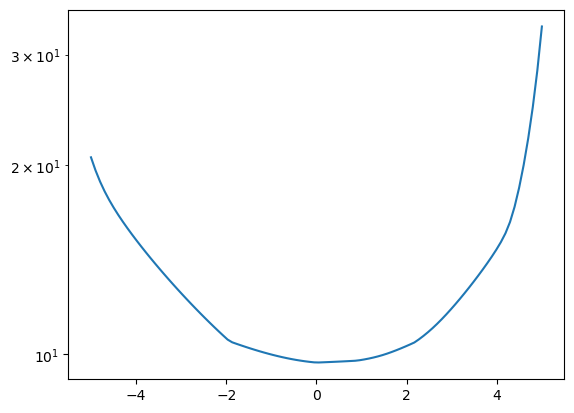

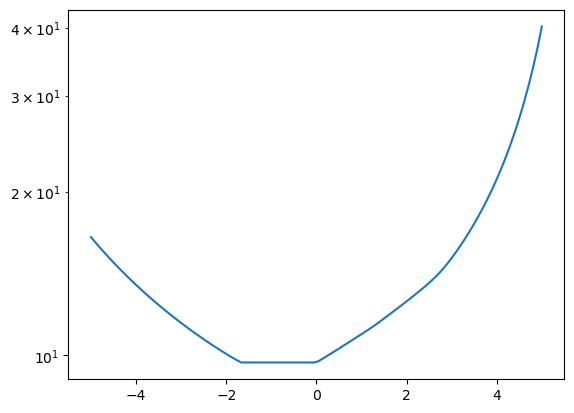

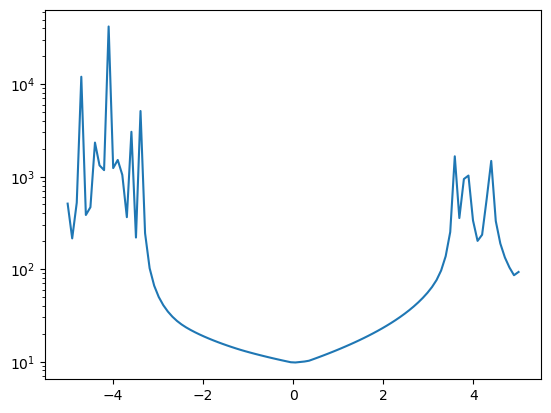

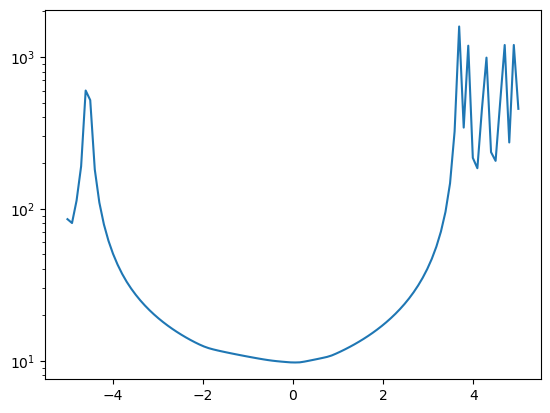

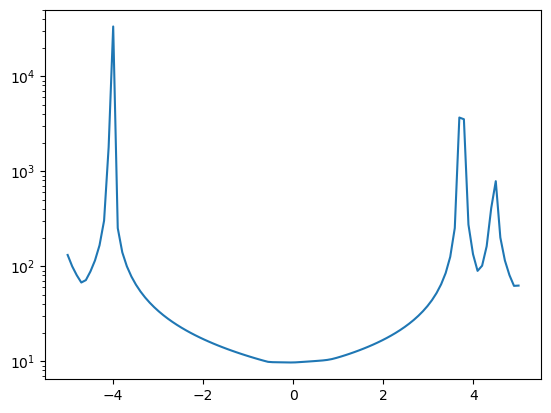

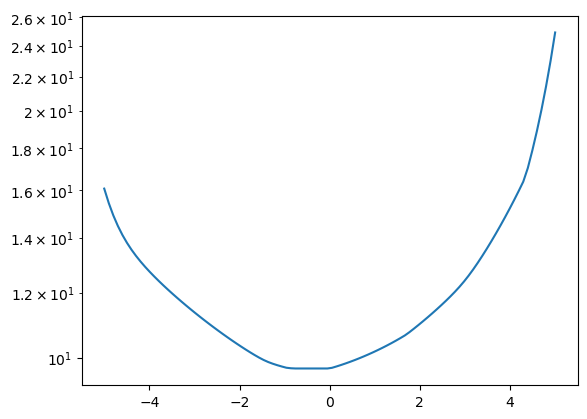

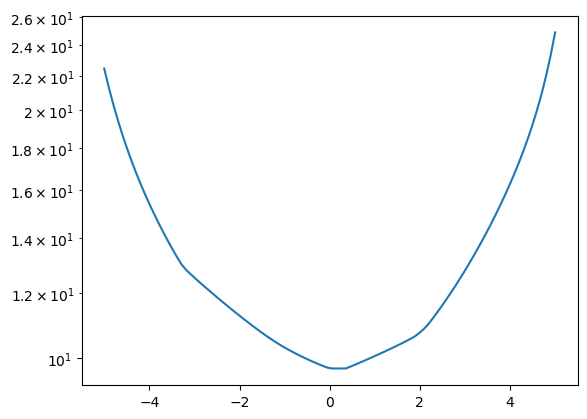

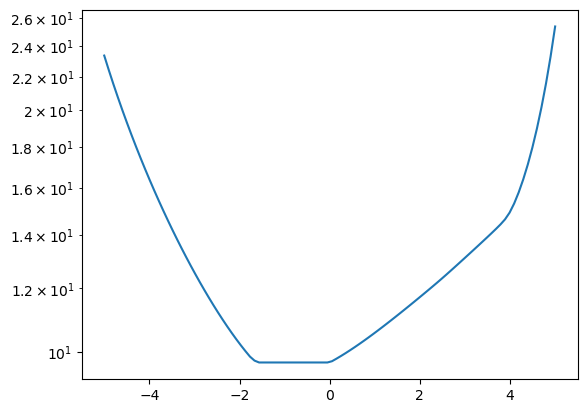

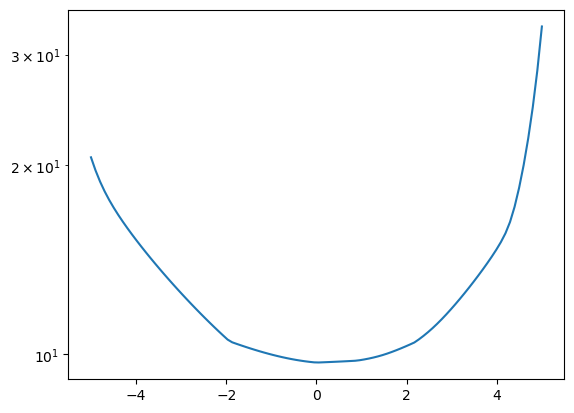

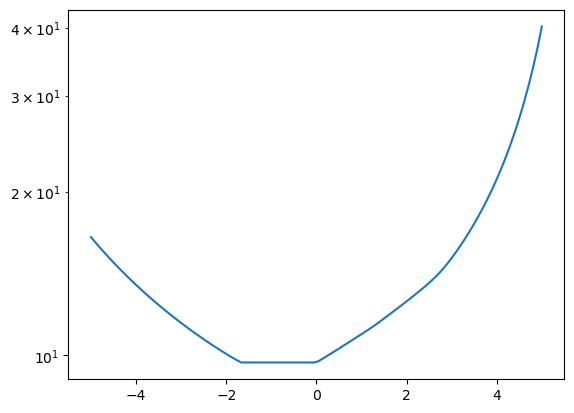

In [164]:
for j in range(numberofclms):
    plt.plot(clmsweep, condnums[j, :])
    plt.yscale('log')
    plt.show()

In [155]:
# cond number sweeps

condvals = np.zeros((nparams, 100), dtype=np.float64)

for p in range(nparams):
    if p < numberofclms:
        sweepvals = np.linspace(-5, 5, 100)
    else:
        sweepvals = np.logspace(-9, -4, 100)
    for i, val in enumerate(sweepvals):
        tstpars={}
        if p < numberofclms and p < nclms[0]:
            valclm = np.zeros(nclms[0])
            valclm[p] = val
            tstpars['gw_clm_f0(8)'] = valclm
        elif p < numberofclms and p >= nclms[0]:
            valclm = np.zeros(nclms[1])
            valclm[p-nclms[0]] = val
            tstpars['gw_clm_f1(8)'] = valclm
        tstpars['gw_log10_rho(2)'] = np.ones(comps)*-6.0

        phiinvhold = m_mdc.globalgp.Phi_inv(tstpars)[0]
        condvals[p, i] = np.linalg.cond(phiinvhold)

KeyError: 'gw_clm_f1(8)'

/tmp/ipykernel_474058/3522211380.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(fidmat)))


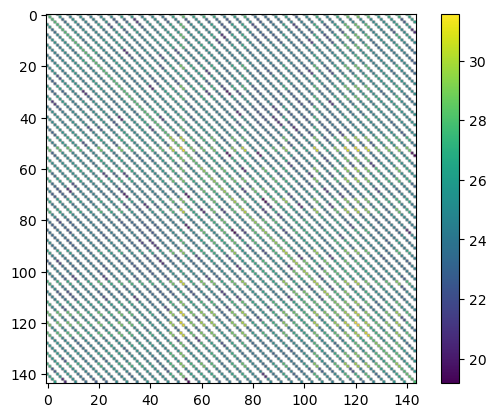

In [112]:
plt.imshow(np.log(np.abs(fidmat)))
plt.colorbar()

In [124]:
eival, eivec = np.linalg.eigh(fidmat)

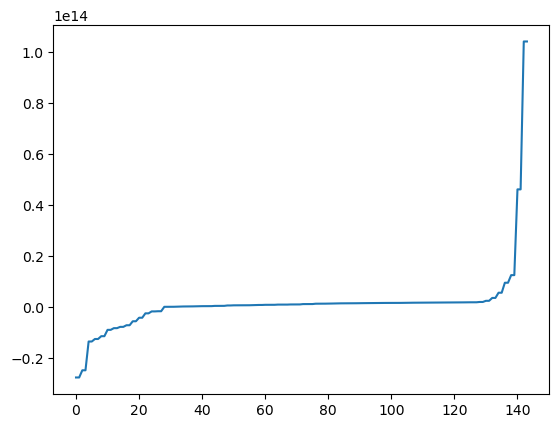

In [125]:
plt.plot(eival)

In [115]:
eival[-1] / eival[0]

np.float64(-7.478061569015499)

In [116]:
np.linalg.cond(phimat)

np.float64(510.3092194274916)

In [58]:
pararr = np.zeros(nparams)
pararr[0] = -5.0
pararr[-2:] = np.ones(comps)*-6.0
constrn_like(pararr)

Array(nan, dtype=float64)

In [60]:
np.linalg.cond(fidmat)

np.float64(510.3092194274895)

In [80]:
a = m_mdc.psls[0].N.make_solve_2d()((m_mdc.globalgp.Fs[0]))[0]
a.shape

(130, 4)

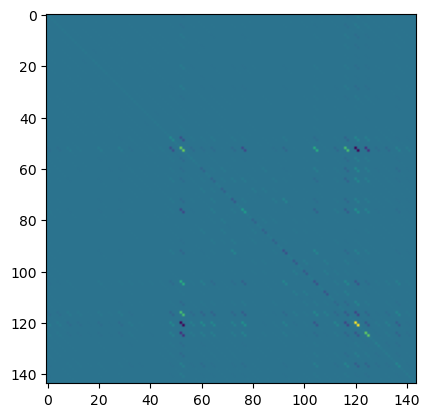

In [87]:
plt.imshow(fidmat)

In [84]:
params = tstpars  
Phi_inv, _ = m_mdc.globalgp.Phi_inv(params)

FtNmF = jnp.zeros_like(Phi_inv)
for psl, F in zip(m_mdc.psls, m_mdc.globalgp.Fs):
    NmF = psl.N.make_solve_2d()(F)[0]
    print(NmF.shape, F.shape)
    print(FtNmF.shape)
    FtNmF = FtNmF + F.T @ NmF

Sigma = Phi_inv + FtNmF

(130, 4) (130, 4)
(144, 144)


TypeError: add got incompatible shapes for broadcasting: (144, 144), (4, 4).

In [166]:
nparams = numberofclms + comps

In [170]:
tstpars = np.zeros(nparams)
tstpars[-2:] = np.ones(comps)*-6.0

In [171]:
tstpars.shape

(18,)

In [173]:
constrn_like(tstpars)

Array(40822.20776774, dtype=float64)

In [174]:
%timeit constrn_like(tstpars).block_until_ready()

1.95 ms ± 81.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [66]:
# l10apri = lambda x: jss.uniform.logpdf(x, -18, 6)
# gampri = lambda x: jss.uniform.logpdf(x, 0, 7)
clmpri = lambda x: jss.uniform.logpdf(x, -3, 6)
rhopri = lambda x: jss.uniform.logpdf(x, -9, 5)

tstpars = np.zeros(nparams)
tstpars[-2:] = np.ones(comps)*-6.0


#@jax.jit
def priorfunc(params):
    
    aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
    clmprival = 0 # LSS a placeholder for the sum of the clm priors
    for c in range(comps):
        clvalues = params[aniparamct:aniparamct+nclms[c]]
        clmprival += jnp.sum(clmpri(clvalues))
        aniparamct += nclms[c]

    rhos = params[-comps:]
    rhoprival = jnp.sum(rhopri(rhos))
    fullpri = clmprival + rhoprival

    smap = dac.clm2map(params[:-comps], nside=16)
    invalidsky = jnp.sum(smap < 0) > 0 # True if sky has negative values
    ret = jnp.where(invalidsky, -jnp.inf, fullpri)
    return ret

priorfunc(tstpars)

Array(-31.88702733, dtype=float64)

In [176]:
%timeit priorfunc(tstpars).block_until_ready()

23.9 μs ± 448 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [22]:
smap = dac.clm2map([np.sqrt(4*np.pi), 0, 0, 0], nside=16)
np.sum(smap < 0)

np.int64(0)

In [26]:
validclms = []

while len(validclms) < 1000:
    randclms = np.random.uniform(low=-3, high=3, size=8)
    #print(randclms.shape)
    randclmswc00 = np.concatenate((np.array([np.sqrt(4*np.pi)]), randclms))
    smap = dac.clm2map(randclmswc00, nside=16)
    invalidsky = np.sum(smap < 0) > 0 # True if sky has negative values
    if not invalidsky:
        validclms.append(randclms)
        print(len(validclms))


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [27]:
validclms = np.array(validclms)

In [28]:
validclms.shape

(1000, 8)

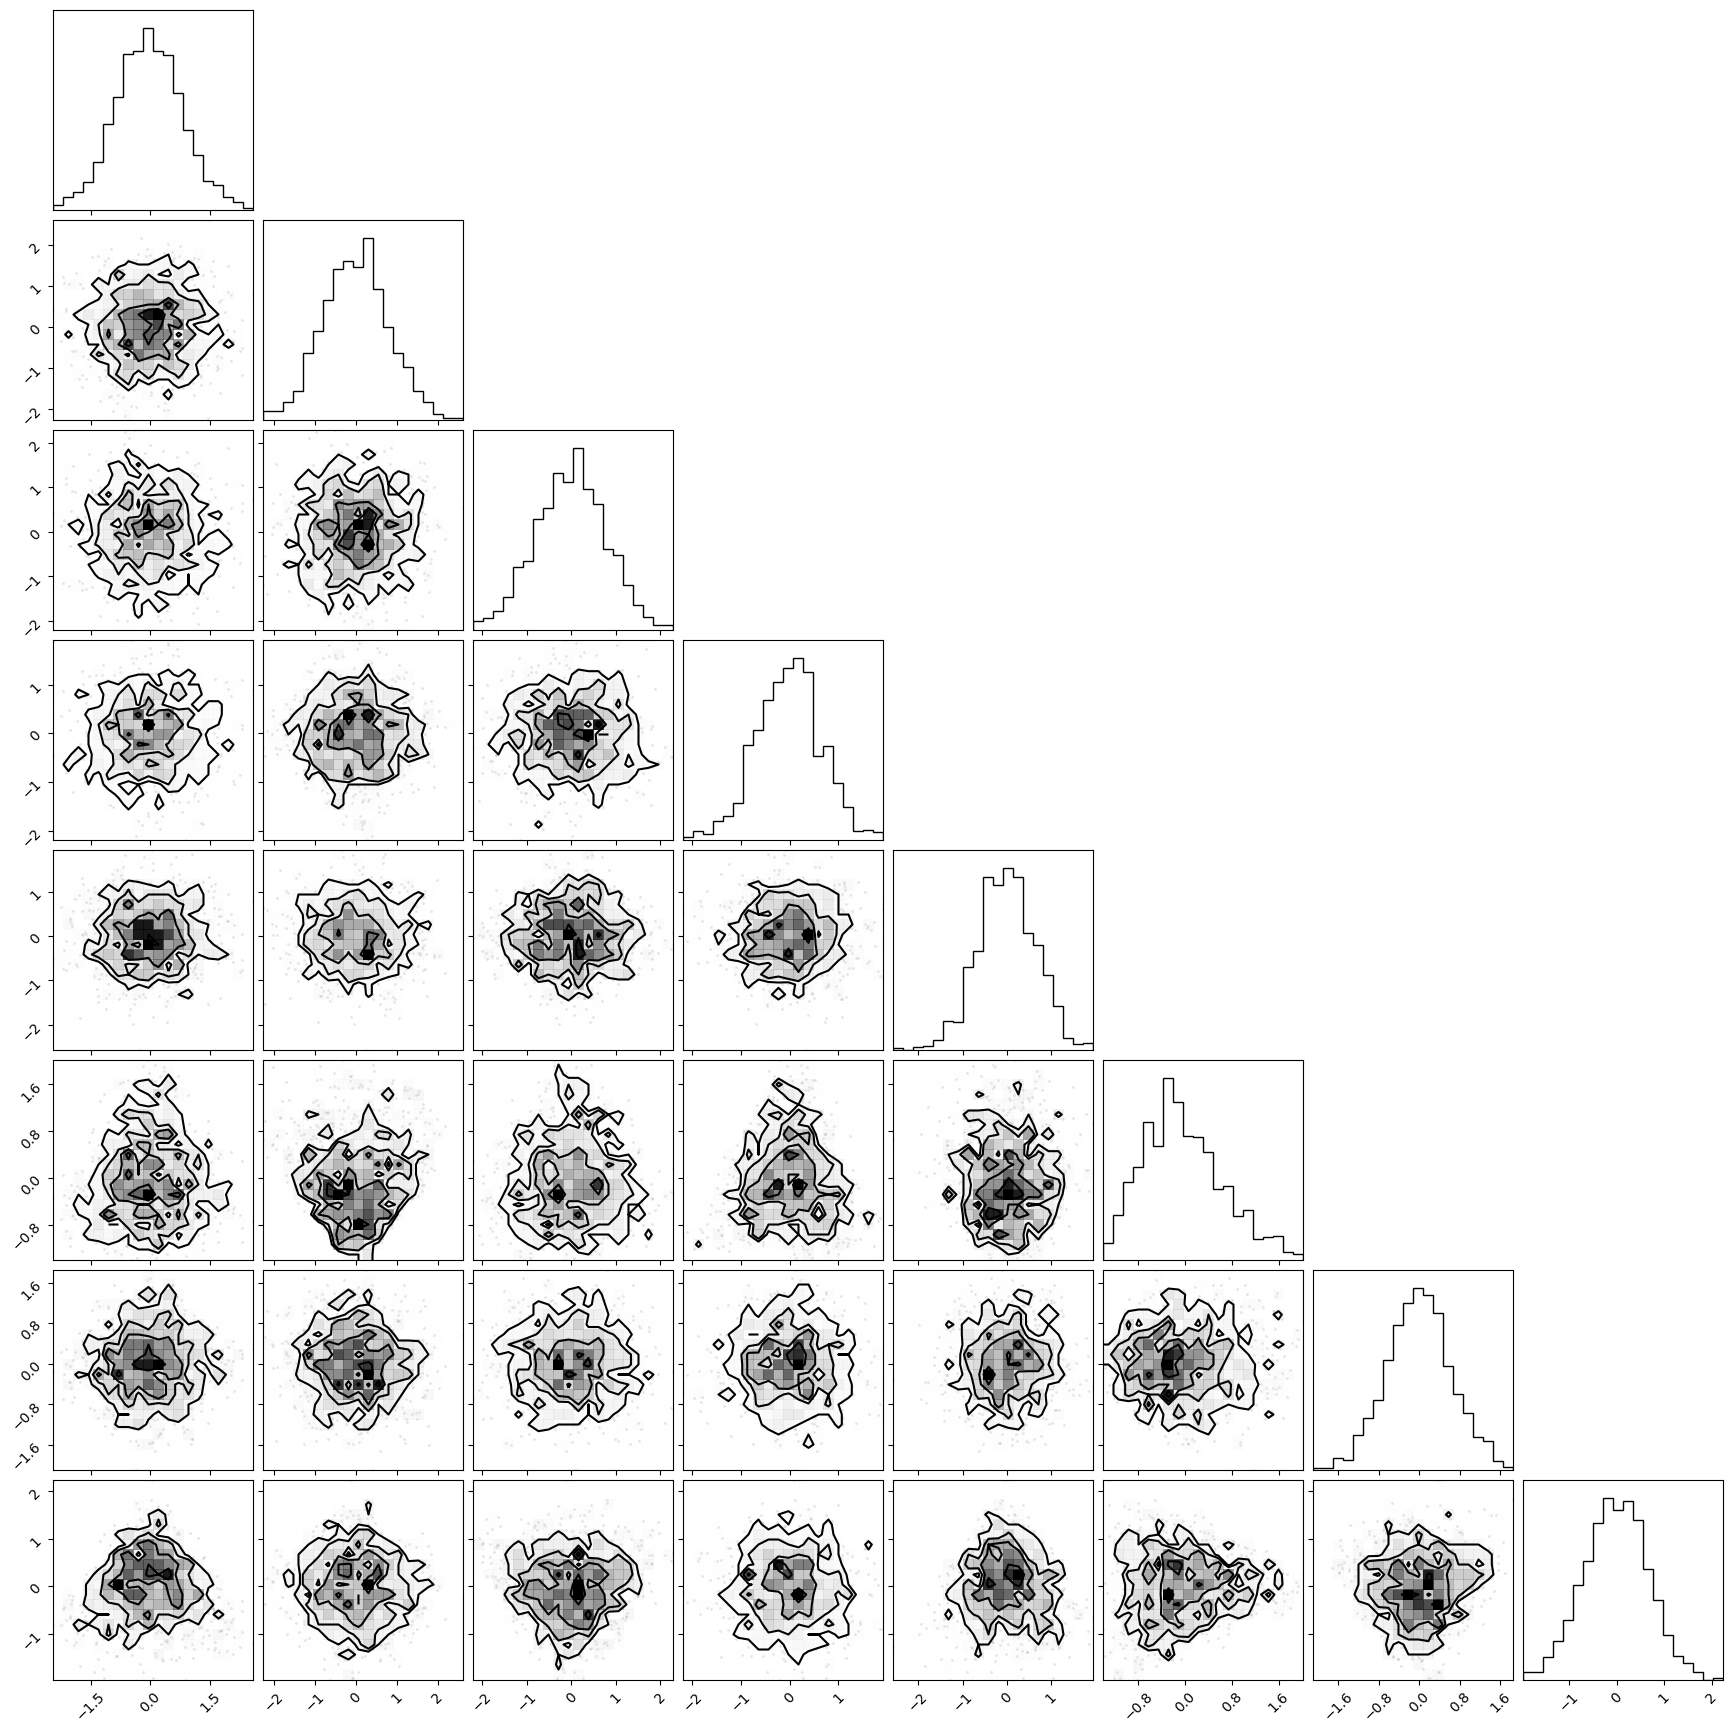

In [30]:
corner(validclms);

In [26]:
# likelihood sweeps

likevals = np.zeros((nparams, 100), dtype=np.float64)

for p in range(nparams):
    tstpars = jnp.zeros(numberofclms + comps)
    tstpars = tstpars.at[-comps:].set(np.ones(comps)*-6.0)
    if p < numberofclms:
        sweepvals = np.linspace(-5, 5, 100)
    else:
        sweepvals = np.logspace(-9, -4, 100)
    for i, val in enumerate(sweepvals):
        tstpars = tstpars.at[p].set(val)
        likevals[p, i] = constrn_like(tstpars)


In [27]:
clmsweep=np.linspace(-5, 5, 100)
np.argmin(np.abs(clmsweep-0))

np.int64(49)

In [35]:
for i, j in zip(clmsweep, likevals[0, :]):
    print(i, j)

-5.0 nan
-4.898989898989899 nan
-4.797979797979798 nan
-4.696969696969697 nan
-4.595959595959596 41772.890690704386
-4.494949494949495 nan
-4.393939393939394 nan
-4.292929292929293 nan
-4.191919191919192 nan
-4.090909090909091 nan
-3.9898989898989896 nan
-3.888888888888889 40062.61028390878
-3.787878787878788 nan
-3.686868686868687 40716.982136632345
-3.5858585858585856 nan
-3.484848484848485 40917.30332466985
-3.383838383838384 nan
-3.282828282828283 40329.00789619301
-3.1818181818181817 40488.32860903579
-3.080808080808081 40566.02805383697
-2.9797979797979797 40615.14870411252
-2.878787878787879 40650.029092857934
-2.7777777777777777 40676.479194467116
-2.676767676767677 40697.3987099502
-2.5757575757575757 40714.43437851207
-2.474747474747475 40728.60732518925
-2.3737373737373737 40740.592298939664
-2.272727272727273 40750.857092028135
-2.1717171717171717 40759.73839605802
-2.070707070707071 40767.485922437656
-1.9696969696969697 40774.289469246665
-1.868686868686869 40780.29626462

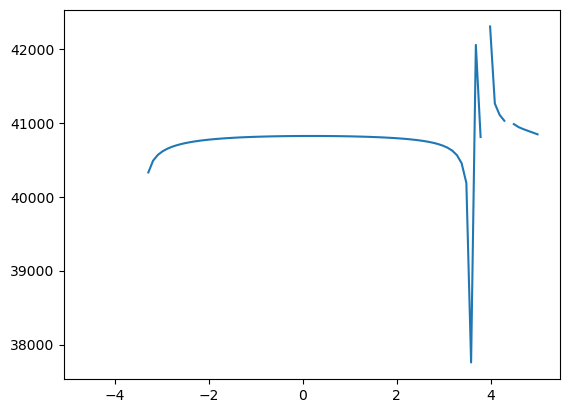

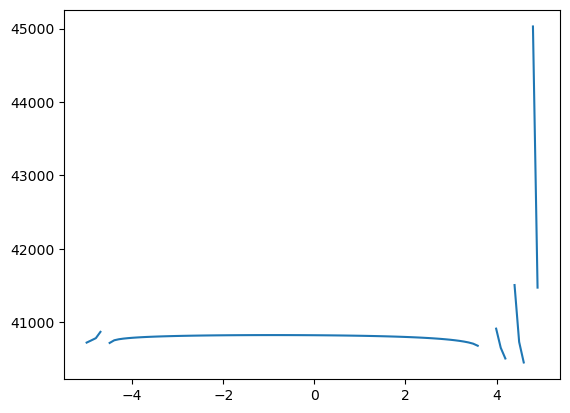

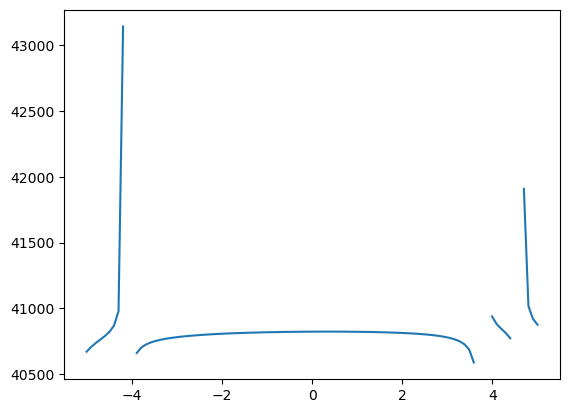

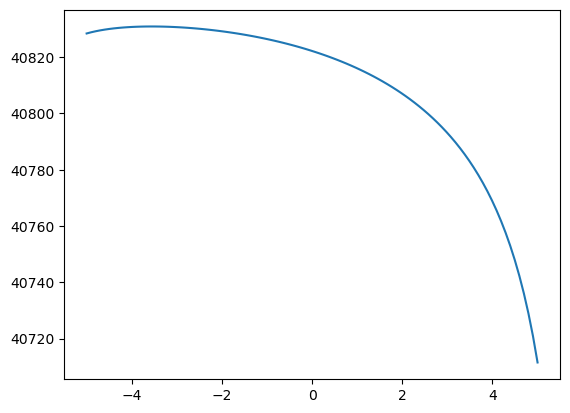

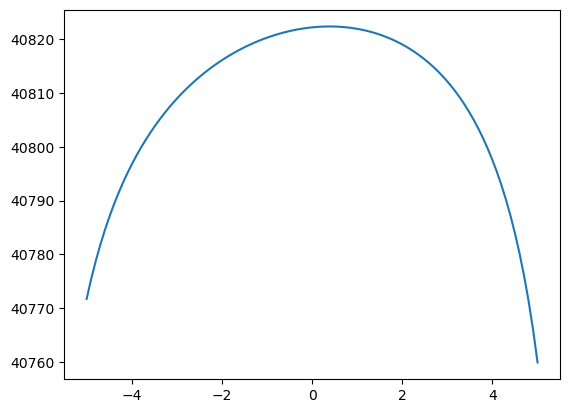

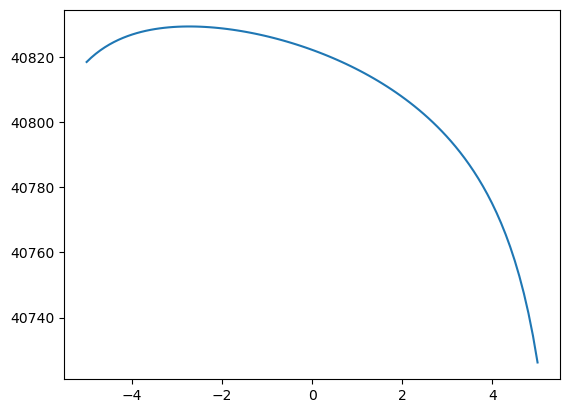

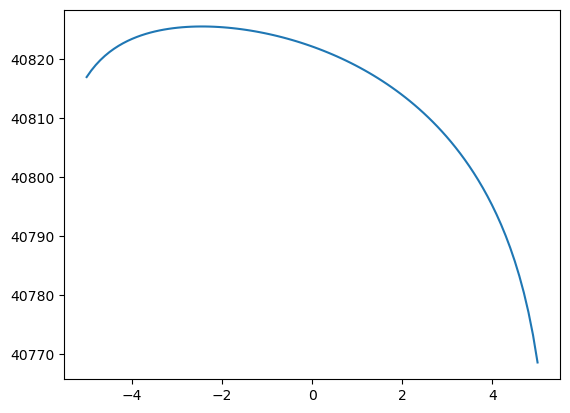

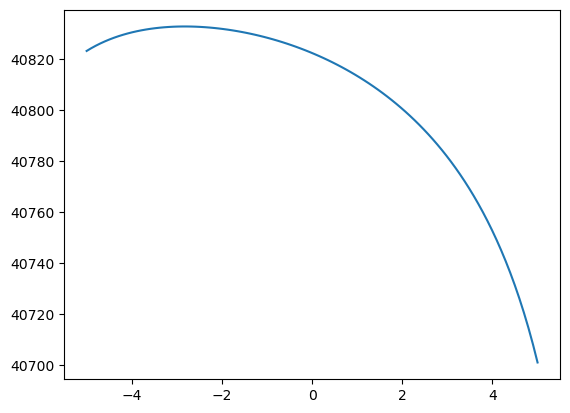

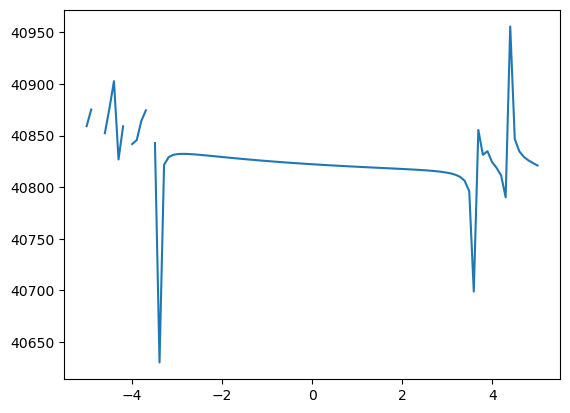

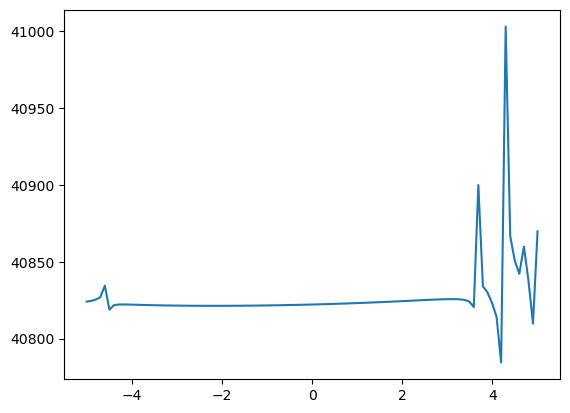

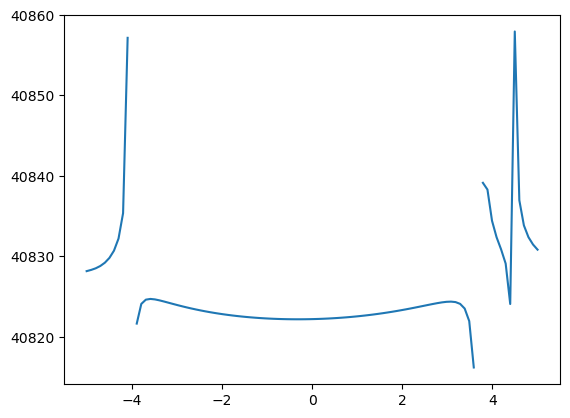

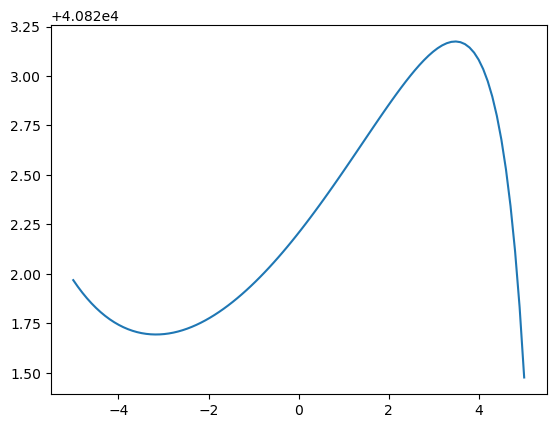

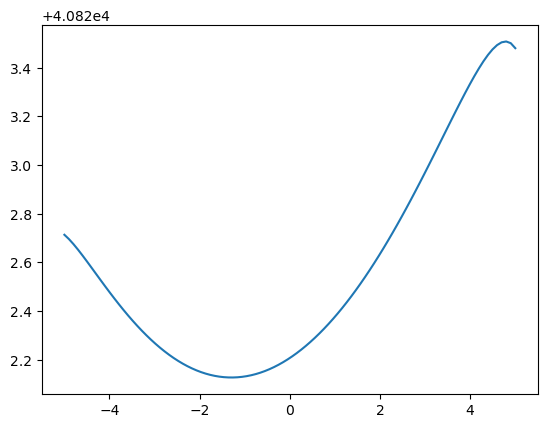

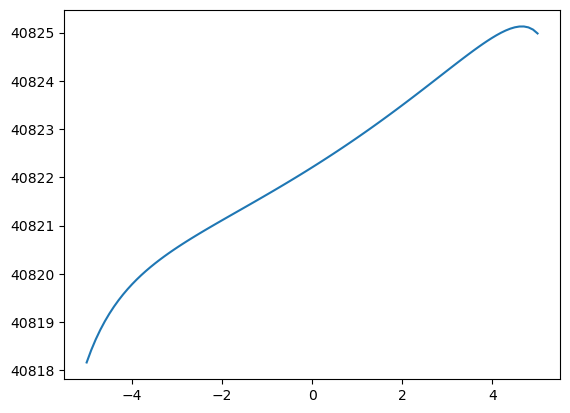

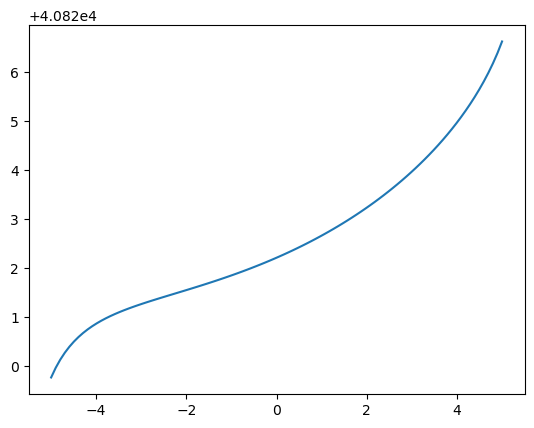

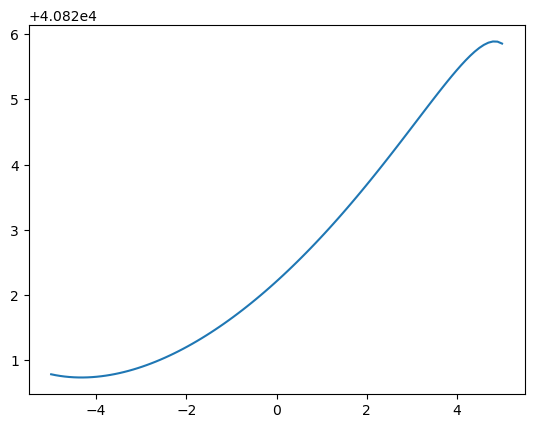

In [28]:
for i in range(numberofclms):
    plt.plot(clmsweep, likevals[i, :])
    plt.show()

In [53]:
np.sum(~np.isfinite(likevals))

np.int64(33)

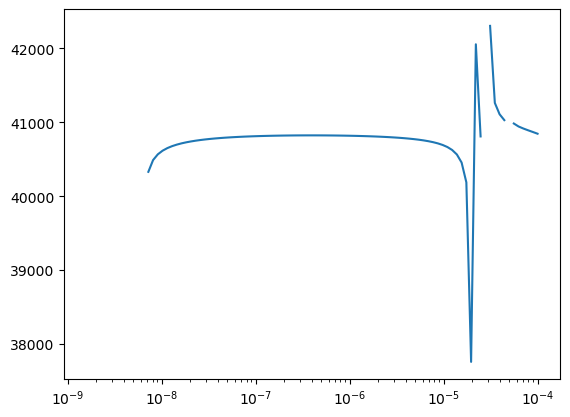

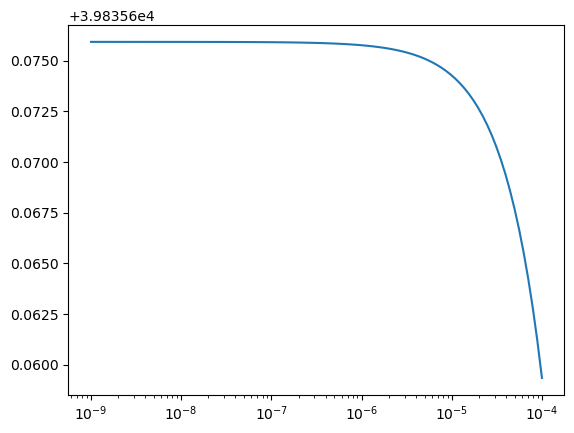

In [50]:
rhosweep=np.logspace(-9, -4, 100)
for i in range(comps):
    plt.plot(rhosweep, likevals[-i, :])
    plt.xscale('log')
    plt.show()

In [177]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [76]:
numberofclms = sum(nclms)

initcov = np.eye(nparams) * 0.01
# sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc,
#                                    logl_grad=likegradjump, logp_grad=prigradjump, cov=initcov,
#                                    outDir=f'./chains/narrow_lm{lmx}_{comps}f_gradjptst/', resume=False)


sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc, cov=initcov,
                                   outDir=f'./chains/narrow_lm{lmx}_{comps}f/', resume=True)

# def nothinglnlike(x):
#     return 1.0



def draw_from_clm_prior(x, iter, beta):
    '''Getting draws from CLM prior'''
    # key = jax.random.PRNGKey(iter)
    q = x.copy()
    # q = jnp.array(x)
    
    lqxy = 0

    # LSS choose random clm - hardcoded what number params this corresponds to
    #randclm = np.random.choice(numberofclms)
    # q = q.at[randclm].set(jax.random.uniform(key, minval=-3, maxval=3))
    q[0:numberofclms] = np.random.uniform(low=-3, high=3, size=numberofclms)

    lqxy = clmpri(q) - clmpri(x)  # log proposal ratio for Metropolis-Hastings
    #lqxy = lqxy.at[-comps:].set(rhopri(q[-comps:]) - rhopri(x[-comps:]))
    lqxy = np.array(lqxy)
    lqxy[-comps:] = np.zeros(comps)
    return q, np.sum(lqxy)

# def drawclmpri_wrap(x, iter, beta):
#     return np.array(draw_from_clm_prior(x, iter, beta))

sampler.addProposalToCycle(draw_from_clm_prior, 50)

In [68]:
draw_from_clm_prior(tstpars, 0, 1.0)

(array([-8.03084005e-01,  5.56338898e-01, -8.34995079e-01,  1.43439100e-01,
        -2.09747877e+00,  8.44318908e-01,  1.49587796e+00,  6.25602031e-01,
         2.46262494e+00,  2.31077079e-01, -2.53015543e+00, -1.01441184e+00,
        -1.59734234e+00, -1.10427286e+00, -1.18913648e+00,  5.37080575e-04,
        -6.00000000e+00, -6.00000000e+00]),
 np.float64(0.0))

In [69]:
# # LSS from William Lamb:
# def draw_from_common_prior(self, x, iter, beta):

#     q = x.copy()
#     lqxy = 0

#     signal_name = 'common red noise'

#     # draw parameter from signal model
#     param = np.random.choice(self.snames[signal_name])

#     if param.size:
#         idx2 = np.random.randint(0, param.size)
#         q[self.pmap[str(param)]][idx2] = param.sample()[idx2]

#     # scalar parameter
#     else:
#         q[self.pmap[str(param)]] = param.sample()


#     # forward-backward jump probability
#     lqxy = (param.get_logpdf(x[self.pmap[str(param)]]) -
#             param.get_logpdf(q[self.pmap[str(param)]]))

#     return q, float(lqxy)

# sampler.JumpProposal.draw_from_common_prior = draw_from_common_prior



In [364]:
# LSS testing clm2map works after jaxification
isoc1ms = np.array([np.sqrt(4*np.pi), 0, 0, 0])

dac.clm2map(isoc1ms, nside=16)

ImportError: Missing optional library 's2fft', part of the 'recommended' dependency group.

In [351]:
jax.devices()

[CudaDevice(id=0)]

In [86]:
sampler.sample(Niter=200000, p0=np.array(tstpars),
               SCAMweight=0, AMweight=25, DEweight=50)

Resuming run from chain file ./chains/narrow_lm2_2f//chain_1.txt
Resuming with 10101 samples from file representing 101001 original samples
Adding DE jump with weight 50
Finished 100.00 percent (100.00 percent of new work) in 265.344655 s Acceptance rate = 0.196614
Run Complete


## Looking at the chain

In [87]:
chn = np.loadtxt(f'/home/levis/ipta_aniso_datachallenge/examples/chains/narrow_lm{lmx}_{comps}f/chain_1.txt')
# chn = np.loadtxt(f'/home/levis/ipta_aniso_datachallenge/examples/chains/priordrawtst/chain_1.txt')

In [88]:
chn.shape

(20001, 22)

In [89]:
chn[:, -4]

array([40790.32074 , 40790.32074 , 40790.32074 , ..., 40903.81364 ,
       40903.81364 , 40904.226422], shape=(20001,))

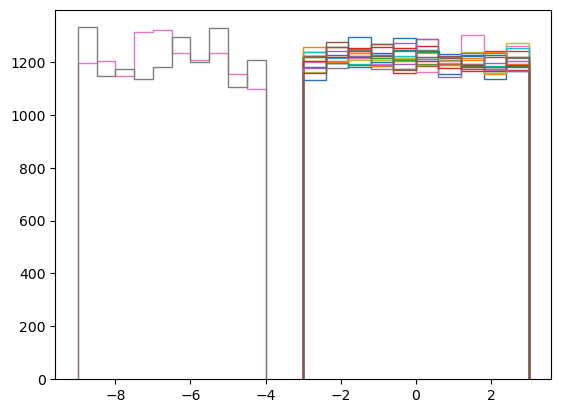

In [356]:
for i in range(nparams):
    plt.hist(chn[:, i], histtype='step')

plt.show()

In [357]:
nparams

18

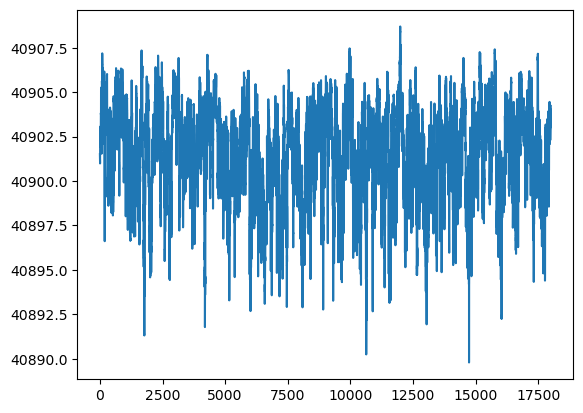

In [92]:
plt.plot(chn[2000:, -4])

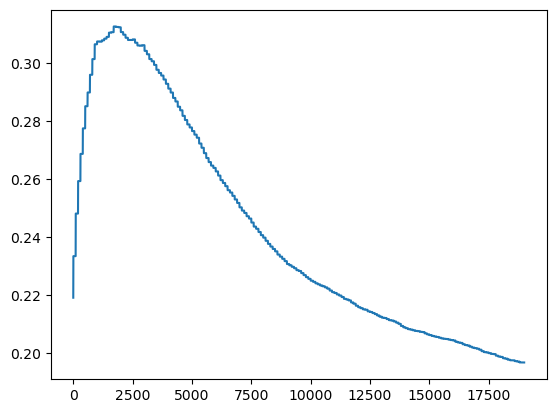

In [91]:
plt.plot(chn[1000:, -2])

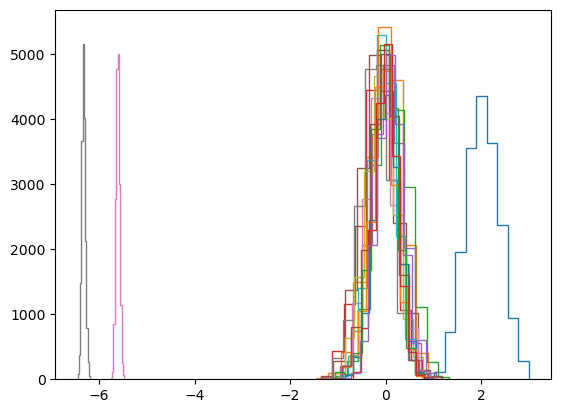

In [94]:
for i in range(nparams):
    plt.hist(chn[2000:, i], histtype='step')

plt.show()

(array([  8.,   3.,   4.,   4.,   3.,  16.,  14.,  10.,  27.,  46.,  56.,
        107., 131., 200., 240., 251., 412., 447., 412., 443., 532., 583.,
        826., 765., 851., 874., 893., 855., 896., 846., 785., 760., 723.,
        742., 628., 624., 492., 451., 429., 375., 281., 230., 165., 169.,
        105.,  95.,  69.,  79.,  31.,  13.]),
 array([0.79269667, 0.83661502, 0.88053337, 0.92445173, 0.96837008,
        1.01228843, 1.05620679, 1.10012514, 1.14404349, 1.18796184,
        1.2318802 , 1.27579855, 1.3197169 , 1.36363525, 1.40755361,
        1.45147196, 1.49539031, 1.53930867, 1.58322702, 1.62714537,
        1.67106372, 1.71498208, 1.75890043, 1.80281878, 1.84673714,
        1.89065549, 1.93457384, 1.97849219, 2.02241055, 2.0663289 ,
        2.11024725, 2.1541656 , 2.19808396, 2.24200231, 2.28592066,
        2.32983902, 2.37375737, 2.41767572, 2.46159407, 2.50551243,
        2.54943078, 2.59334913, 2.63726748, 2.68118584, 2.72510419,
        2.76902254, 2.8129409 , 2.85685925, 2.

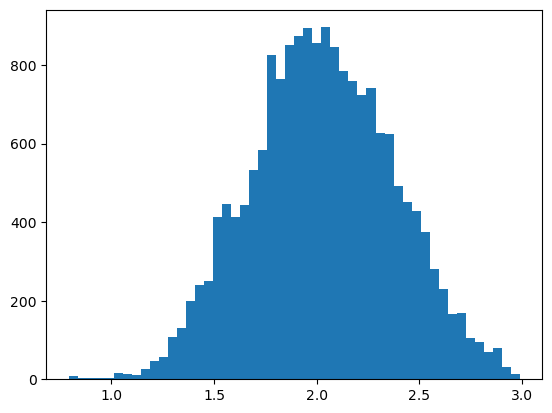

In [95]:
plt.hist(chn[2000:, 0], bins=50)

In [122]:
lmx

2

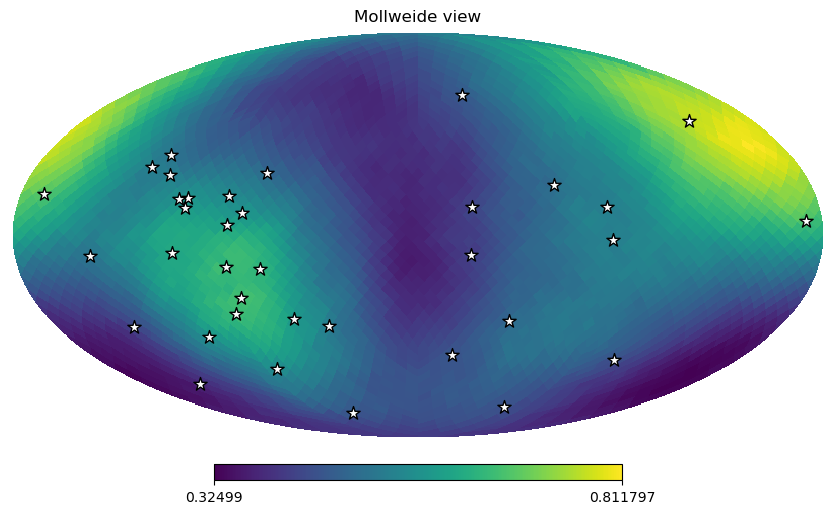

In [114]:
nsi = 16
smaps = []
for i in np.random.randint(2000, chn.shape[0], 1000):
    smaps.append(dac.clm2map(chn[i, :numberofclms], nside=nsi))
hp.mollview(np.median(smaps, axis=0), rot=180)
dac.plot_pulsars(psrs)


In [120]:
numberofclms

16

In [121]:
chn.shape

(20001, 22)

In [126]:
nclms

[8, 8]

In [127]:
print(lmx)
holdangpowf1 = np.zeros((1000, lmx))
holdangpowf2 = np.zeros((1000, lmx))
for i_idx, i in enumerate(np.random.randint(2000, chn.shape[0], 1000)):
    holdangpowf1[i_idx, :] = dac.clm2angpowspec(chn[i, :nclms[0]], lmax=lmx)
    holdangpowf2[i_idx, :] = dac.clm2angpowspec(chn[i, nclms[0]:nclms[1]+nclms[0]], lmax=lmx)

2


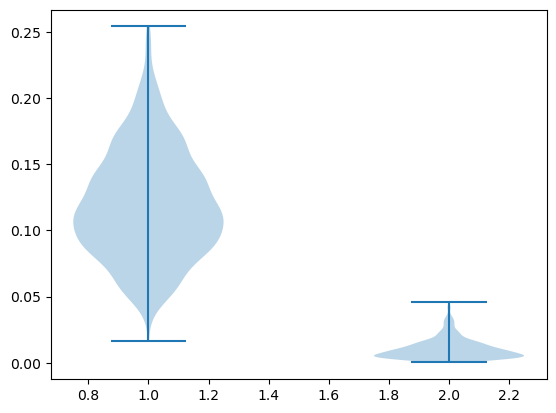

In [128]:
plt.violinplot(holdangpowf1/(4*np.pi), positions=np.arange(1, lmx+1));

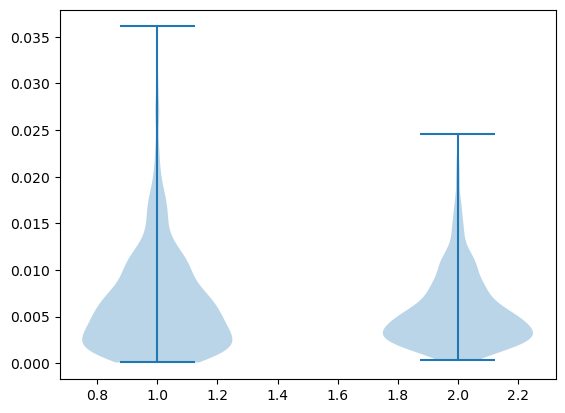

In [130]:
plt.violinplot(holdangpowf2/(4*np.pi), positions=np.arange(1, lmx+1));

(array([1363.,    0.,    0.,    0.,    0.,    0.,  139.,    0.,    0.,
        4399.]),
 array([1.10212521e+15, 1.19414769e+16, 2.27808286e+16, 3.36201804e+16,
        4.44595321e+16, 5.52988838e+16, 6.61382355e+16, 7.69775873e+16,
        8.78169390e+16, 9.86562907e+16, 1.09495642e+17]),
 <BarContainer object of 10 artists>)

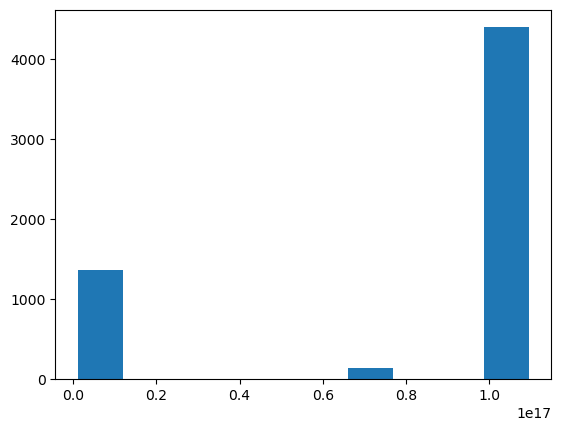

In [209]:
plt.hist(chn[10000:, -4])